##Metaheuristische Betriebsoptimierung

1. **Systemintegration:** Verknüpfung von PV-Erzeugungsprognosen und historischen Lastprofilen.
2. **Simulation elektrischer Speicher:** Nachbildung des Lade- und Entladeverhaltens ($SOC$-Bilanzierung).
3. **Heuristische Optimierung:** Anwendung **Genetischer Algorithmen (GA)** mittels `DEAP` zur Kostenminimierung.

---

# Schritt 1: Vorbereitung & Mounten von Google Drive

## Umgebung vorbereiten
Zuerst installeiren wir die notwendige Bibliotheken (wie `deap` für Optimierung, `nbformat` zum Lesen von Notebooks) und verbinden Google Drive.  

---

## Notebook als „Bibliothek“ verwenden (`load_notebook`)

Das Notebook wird wie einer Textdatei geöffnet.  
Die Funktion `nbformat` liest dabei die Struktur aus.  
`InteractiveShell` führt jede Code-Zelle im Hintergrund aus.

---

## Variablen-Mapping

Jetzt werden gezielt die Ergebnisse herausgesucht, die für die weitere Berechnung gebraucht werden:

- `P_PV_out_AC`: Die erzeugte PV-Leistung aus dem PV-Modell  
- `medoid_week`: Das typische Lastprofil aus dem Clustering-Modell  

---

**Vorteil:**  
„Warum machen wir das so, statt einfach den Code zu kopieren?“  
→ Antwort: Wartbarkeit! Wenn sich im PV-Modell etwas ändert, wird das Ergebnis automatisch im Haupt-Skript aktualisiert.

**Risiko:**  
„Was passiert, wenn sich Variablen-Namen im PV-Notebook ändern?“  
→ Antwort: Die Schnittstelle bricht – man spricht von einer gekoppelten Abhängigkeit. Das ist ein wichtiger Hinweis auf die Bedeutung von sauberen Schnittstellen/APIs.

**Erweiterung:**  
„Wie könnte man das noch sauberer lösen?“  
→ Den Code in echte `.py`-Dateien auslagern und mit `import` einbinden, anstatt Notebooks als Module zu laden.

In [ ]:
!pip install deap pandas numpy matplotlib

from google.colab import drive
drive.mount('/content/drive')

import os
import io
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms
import nbformat
from IPython.core.interactiveshell import InteractiveShell
from google.colab import files

warnings.filterwarnings("ignore")

# Funktion zum Laden eines Notebooks als Modul-Ersatz
def load_notebook(notebook_path):
    with open(notebook_path, 'r', encoding='utf-8') as f:
        nb = nbformat.read(f, as_version=4)

    # Erstelle eine neue Shell, um das Notebook auszuführen
    shell = InteractiveShell.instance()

    # Führt alle Zellen im Notebook aus, um Variablen verfügbar zu machen
    for cell in nb.cells:
        if cell.cell_type == 'code':
            shell.run_cell(cell.source)
    return shell.user_ns # Gibt den Namespace (alle Variablen) des Notebooks zurück

# Pfad den Notebooks (sicherstellen, dass sie im gleichen Ordner liegen)
base_path = '/content/drive/MyDrive/Colab Notebooks/'

# Notebooks laden
print("Lade PV_Prognose...")
pv_mod = load_notebook(base_path + 'Kopie von PV_Prognose.ipynb')

print("Lade Lastprofil_Clustering...")
strom_mod = load_notebook(base_path + 'Kopie von Lastprofil_Clustering.ipynb')

# --- DATEN-ZUGRIFFS-KORREKTUR ---
# Wir nutzen die Dictionaries 'pv_mod' und 'strom_mod', die wir per load_notebook geladen haben.

try:
    # Direkter Zugriff auf die geladenen Variablen aus den Notebook-Dictionaries
    pv_data_series = pv_mod['P_PV_out_AC']

    load_data = strom_mod['mean_week']

    IMPORTS_SUCCESSFUL = True
    print(" -> Daten erfolgreich aus Notebook-Dictionaries gemappt.")
except Exception as e:
    print(f" -> Fehler beim Mapping der Daten: {e}")
    IMPORTS_SUCCESSFUL = False


In [ ]:
# --- UI EINGABEMASKE ---

timestep = 1.0
#@title Batteriespeicher-Konfiguration { run: "auto" }
C_Batt_storage = 20 #@param {type:"slider", min:1.0, max:50.0, step:0.5}
P_Charge_Batt = 10 #@param {type:"slider", min:0.5, max:25.0, step:0.5}
P_Discharge_Batt = 10 #@param {type:"slider", min:0.5, max:25.0, step:0.5}
initial_storage = 0.0 #@param {type:"slider", min:0.0, max:10.0, step:0.1}

# Optional: Kurze Validierung, damit die Leistung nicht die Kapazität logisch sprengt
P_Charge_Batt = min(P_Charge_Batt, C_Batt_storage * 2)
P_Discharge_Batt = min(P_Discharge_Batt, C_Batt_storage * 2)

# =========================================================
# DATEN-SCHNITTSTELLE: ORIENTIERUNG AN DER PV-PROGNOSE
# =========================================================
def load_and_merge_to_pv_horizon():
    # 1. PV-Daten (unverändert)
    if IMPORTS_SUCCESSFUL:
        pv_data = pv_mod['P_PV_out_AC'].sort_index()
        if not isinstance(pv_data.index, pd.DatetimeIndex):
            pv_data.index = pd.date_range(start=pd.Timestamp.now(), periods=len(pv_data), freq="min")
        pv_hourly = pv_data.resample("h").mean()
    else:
        idx = pd.date_range("2026-01-01", periods=24, freq="h")
        pv_hourly = pd.Series([max(0, np.sin(i / 24 * np.pi) * 4.5) for i in range(24)], index=idx)

    timeseries = pd.DataFrame(index=pv_hourly.index)
    timeseries["pv"] = pv_hourly.fillna(0) / 1000.0

    # 2. Preisliste mit sicherem Upload-Handling
    start_dt = timeseries.index[0]
    reference_dt = pd.Timestamp(year=start_dt.year, month=1, day=1, hour=0)
    hours_offset = int((start_dt - reference_dt).total_seconds() / 3600)

    path = "/content/drive/MyDrive/Colab Notebooks/Spotmarktpreise.txt"

    if os.path.exists(path):
        prices_raw = pd.read_csv(path, header=None, comment='[').squeeze().values
    else:
        print("Datei 'Spotmarktpreise.txt' nicht im Drive gefunden!")
        print("Bitte lade die Datei jetzt manuell hoch:")
        uploaded = files.upload()
        fname = list(uploaded.keys())[0]

        # 1. Datei für die aktuelle Berechnung laden
        prices_raw = pd.read_csv(io.BytesIO(uploaded[fname]), header=None, comment='[').squeeze().values

        # 2. Datei dauerhaft in das Google Drive Verzeichnis kopieren
        import shutil
        # Sicherstellen, dass das Verzeichnis existiert
        os.makedirs(os.path.dirname(path), exist_ok=True)

        # Wir speichern den Inhalt als Datei ab
        with open(path, 'wb') as f:
            f.write(uploaded[fname])

        print(f"Datei wurde erfolgreich in '{path}' gespeichert und ist ab jetzt dauerhaft verfügbar.")

    n = len(timeseries)
    indices = [(hours_offset + i) % len(prices_raw) for i in range(n)]
    timeseries["feed_in"] = prices_raw[indices] / 100
    timeseries["tariff"] = timeseries["feed_in"]

    # 3. Lastprofil
    load_base = pd.Series(load_data)
    start_h = timeseries.index[0].dayofweek * 24 + timeseries.index[0].hour
    indices = [(start_h + i) % 168 for i in range(len(timeseries))]
    timeseries["demand_el"] = load_base.iloc[indices].values

    return timeseries

timeseries = load_and_merge_to_pv_horizon()

#Schritt 2: Parsen und vereinheitlichen der Zeitreihen

---

##Basisparameter (Batterie)
- Definition der Simulationszeitauflösung (`timestep = 1`)
- Festlegung der Batteriespeichergröße (`10 kWh`)
- Begrenzung der Ladeleistung auf 50% der Kapazität
- Begrenzung der Entladeleistung auf 50% der Kapazität
- Initialer Ladezustand wird auf 0 gesetzt

---

##Aufbau der Funktion `load_and_merge_to_pv_horizon()`

### Zeithorizont bestimmen
- Prüfen, ob externe PV-Daten verfügbar sind
- Falls PV-Daten vorhanden:
  - PV-Zeitreihe wird geladen
  - Aggregation auf Stundenwerte (`resample("h")`)
  - Bestimmung von Start- und Endzeit
- Falls keine Zeitinformationen vorhanden:
  - Erzeugung eines künstlichen Zeitindex (Minuten → Stunden)
- Fallback:
  - Standard-Zeitraum (24h für ein fixes Datum)

---

### Zeitindex erstellen
- Erzeugung eines stündlichen Zeitrasters (`pd.date_range`)
- Initialisierung eines leeren DataFrames als Simulationsbasis

---

### Strompreise einlesen
- Laden der Spotmarktpreise aus Textdatei
- Filterung ungültiger Einträge
- Anpassung der Preisreihe auf Simulationslänge (ggf. Wiederholung)
- Umrechnung in €/kWh
- Aufbau der Preisstruktur:
  - `tariff = Spot + Netzgebühren + Steuern + Aufschläge`
  - `feed_in = Spotpreis`

---

### Kostenbestandteile des Strompreises für Gewerbe (2026)

| Kostenblock | Wert (ca. ct/kWh) | Anmerkung |
| :--- | :--- | :--- |
| **Börsenpreis (Spot)** | *variabel* | Abhängig von Nachfrage & Erzeugung |
| **Netzentgelte** | 9,50 | Regional abhängig (Schätzwert) |
| **KWKG-Umlage** | 0,45 | Gesetzliche Umlage |
| **Offshore-Netzumlage** | 0,94 | Gesetzliche Umlage |
| **§ 19 StromNEV-Umlage** | 1,56 | Gesetzliche Umlage |
| **Konzessionsabgabe** | 1,67 | Abgabe an Kommune |
| **Stromsteuer** | 2,05 | Regelsteuersatz |
| **Gesamt-Aufschlag (exkl. Spot)** | **ca. 16,17** | *zzgl. 19% MwSt auf Gesamtsumme* |

---

### PV-Daten integrieren
- Einfügen der PV-Leistung in den Zeitindex
- Synchronisation über Zeitstempel (`reindex`)
- Fehlende Werte werden auf 0 gesetzt
- Umrechnung in kW

---

### Lastprofil integrieren
- Laden eines typischen Lastprofils (Medoid aus Clustering)
- Bestimmung des Wochentags
- Auswahl des passenden 24h-Startsegments aus einem 168h-Wochenprofil
- Zyklische Zuordnung der Last auf alle Zeitschritte
- Ausgabe der maximalen Last zur Kontrolle

---

### Fallback-Szenario (ohne externe Daten)
- PV wird als sinusförmiger Tagesverlauf erzeugt
- Last wird synthetisch über einfache Sinusfunktion generiert

---

## Ergebnis
Die Funktion gibt einen DataFrame zurück mit:

- ☀️ PV-Erzeugung (`pv`)
- 🏠 Elektrische Last (`demand_el`)
- 💰 Strombezugspreis (`tariff`)
- ⚡ Einspeisevergütung (`feed_in`)

##Schritt 2.1 Zeitreihenplot der Eingangsdaten

In [ ]:
def plot_energy_timeseries(timeseries):
    fig, ax1 = plt.subplots(figsize=(14, 6))

    # --- PV & Last (linke Achse) ---
    ax1.plot(timeseries.index, timeseries["pv"],
             label="PV (kW)", linewidth=2, color="yellow")

    ax1.plot(timeseries.index, timeseries["demand_el"],
             label="Last (kW)", linewidth=2, color="red")

    ax1.set_xlabel("Zeit")
    ax1.set_ylabel("Leistung (kW)")
    ax1.grid(True, alpha=0.3)

    # --- Preise (rechte Achse) ---
    ax2 = ax1.twinx()

    ax2.plot(timeseries.index, timeseries["tariff"],
             label="Strompreis (€/kWh)", linestyle="--", color="black")

    ax2.plot(timeseries.index, timeseries["feed_in"],
             label="Einspeisevergütung (€/kWh)", linestyle=":", color="black", alpha=0.6)

    ax2.set_ylabel("Preis (€/kWh)")

    # --- gemeinsame Legende ---
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()

    # bbox_to_anchor=(x, y) verschiebt die Legende
    # loc="upper left" gibt den Ankerpunkt der Legenden-Box an
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2,
               loc="upper left",
               bbox_to_anchor=(1.05, 1.0))

    plt.title("Energiezeitreihe: PV, Last und Strompreise")

    # WICHTIG: tight_layout() schneidet bei Legenden außerhalb des Plots
    # oft etwas ab. Nutze lieber einen kleinen Rand-Abstand:
    plt.subplots_adjust(right=0.85)
    plt.show()

plot_energy_timeseries(timeseries)

## Schritt 3: Batteriespeicher Be- und Entladelogik

Die Funktion `core_simulation` berechnet den operativen Betrieb des Speichers basierend auf einem vorgegebenen Zeitplan (`schedule`).

**Prioritäten-Regeln:**
1. **Externer Steuerbefehl:** Ladung aus dem Netz basierend auf `schedule` (sofern Kapazität vorhanden).
2. **PV-Eigenverbrauch:** Deckung der Last durch PV.
3. **Batterie-Ladung:** PV-Überschuss füllt den Speicher.
4. **Batterie-Entladung:** Defizitdeckung durch Speicher.
5. **Netzbezug/Einspeisung:** Resultierender Austausch mit dem öffentlichen Stromnetz.

**Berechnete Metriken:**
* `SOC`: Füllstand des Speichers in kWh.
* `from_grid`: Summe aus Netzbezug zur Lastdeckung und Netzladung.
* `to_grid`: PV-Einspeisung.
* `costs`: Bilanz aus Bezugskosten und Einspeiseerlösen.

In [6]:
# =========================================================
# CORE SIMULATION
# =========================================================
def core_simulation(timeseries, schedule):
    soc = initial_storage
    soc_list, actual_from_grid, actual_to_grid, p_charge_grid_list = [], [], [], []

    factor = len(timeseries) // len(schedule)
    repeated_schedule = np.repeat(schedule, factor)
    if len(repeated_schedule) < len(timeseries):
        repeated_schedule = np.pad(repeated_schedule, (0, len(timeseries) - len(repeated_schedule)), mode='edge')
    else:
        repeated_schedule = repeated_schedule[:len(timeseries)]

    for idx, row in enumerate(timeseries.itertuples()):
        pv_power = row.pv
        load = row.demand_el
        ga_cmd = repeated_schedule[idx]

        # Initiale Variablen
        from_grid = 0.0
        to_grid = 0.0
        p_charge_grid = 0.0

        # 1. GA-BEFEHLE VERARBEITEN
        # Zustand 1: Netzladung
        if ga_cmd == 1:
            p_charge_grid = min(P_Charge_Batt, (C_Batt_storage - soc) / timestep)
            soc += p_charge_grid * timestep

        # 2. PV-ÜBERSCHUSS UND HAUSLAST
        net_bi = pv_power - load

        if net_bi > 0:
            # Überschuss: PV lädt Batterie
            pv_to_battery = min(net_bi, (C_Batt_storage - soc) / timestep, P_Charge_Batt)
            soc += pv_to_battery * timestep
            to_grid = net_bi - pv_to_battery
        else:
            # Defizit: Batterie entlädt für Hauslast
            needed_power = abs(net_bi)
            battery_discharging = min(needed_power, soc / timestep, P_Discharge_Batt)
            soc -= battery_discharging * timestep
            from_grid = needed_power - battery_discharging

        # 3. ZUSTAND 2: ARBITRAGE (ENTLADUNG INS NETZ)
        # Wenn noch SOC da ist und GA Befehl 2 gibt:
        if ga_cmd == 2 and soc > 0:
            arbitrage_power = min(soc / timestep, P_Discharge_Batt)
            soc -= arbitrage_power * timestep
            to_grid += arbitrage_power # Verkauf ins Netz

        # Listen befüllen
        soc_list.append(soc)
        actual_from_grid.append(from_grid + p_charge_grid)
        actual_to_grid.append(to_grid)
        p_charge_grid_list.append(p_charge_grid)

    res = timeseries.copy()
    res["SOC"] = soc_list
    res["from_grid"] = actual_from_grid
    res["to_grid"] = actual_to_grid
    res["P_Charge_From_Grid"] = p_charge_grid_list
    res["battery_charge_signal"] = repeated_schedule
    res["costs"] = (res["from_grid"] * res["tariff"]) - (res["to_grid"] * res["feed_in"])
    return res

## Schritt 4: Genetischer Algorithmus (GA)

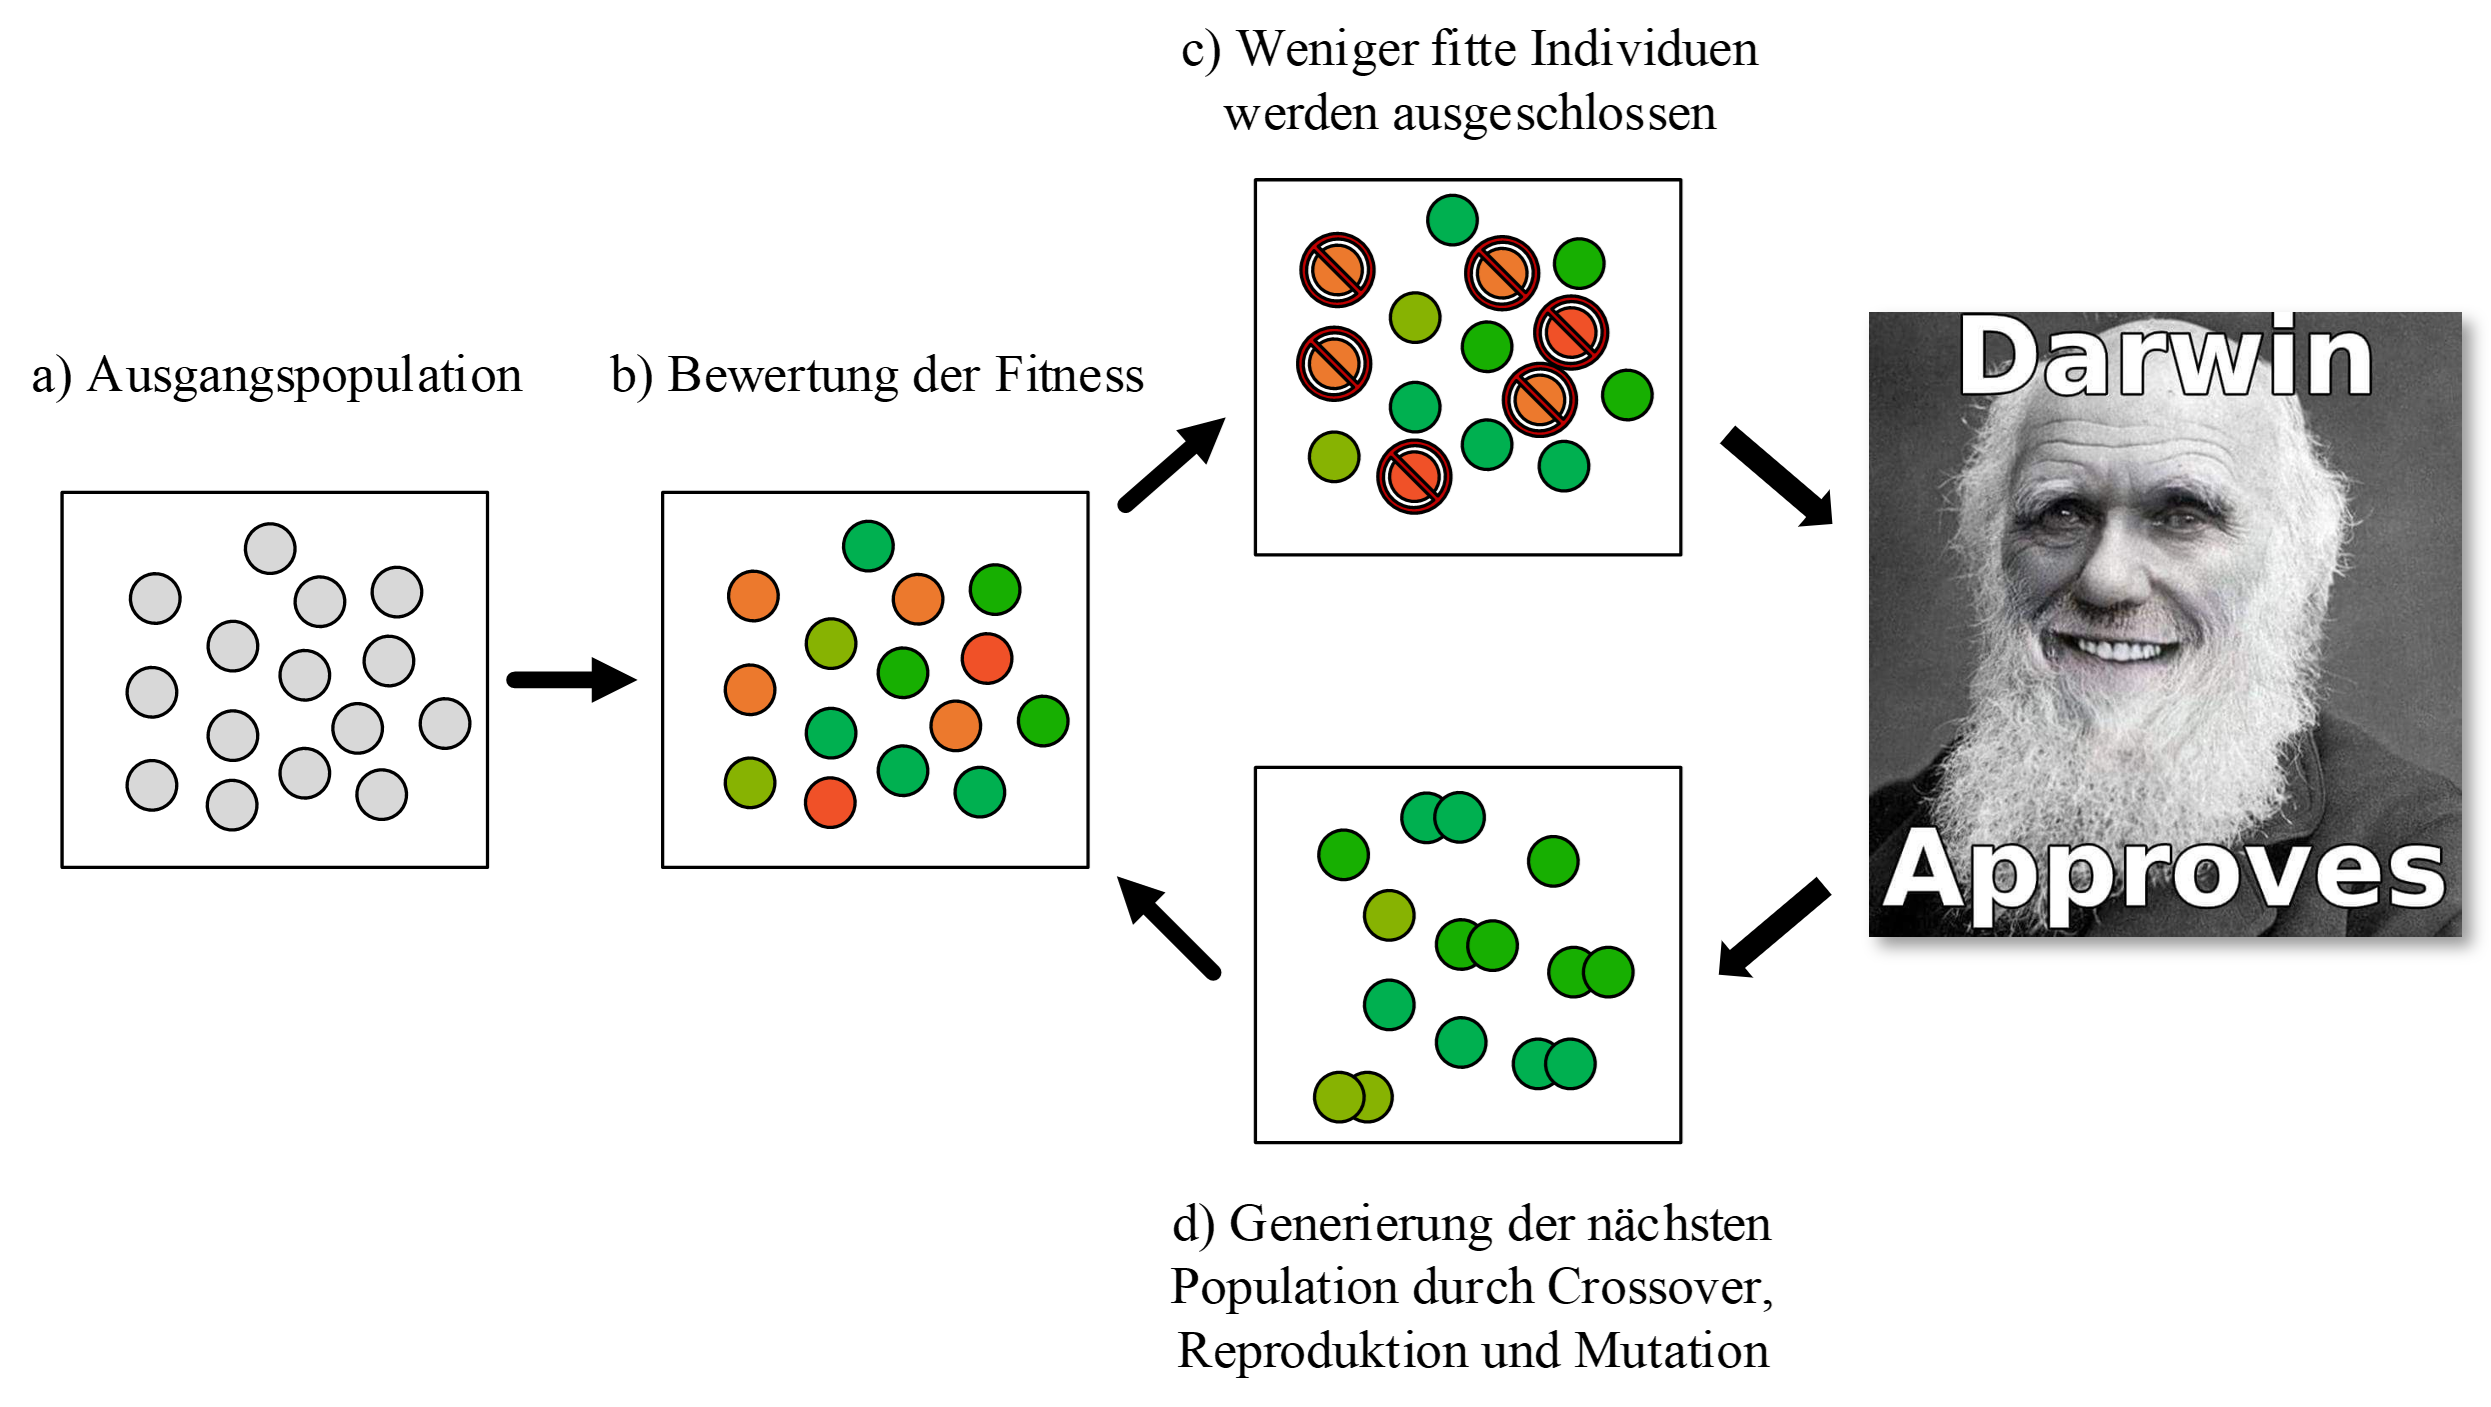

Das Optimierungsproblem wird mittels `DEAP` gelöst, um die Kosten des Gesamtsystems zu minimieren.

**Konfiguration:**
* **Individuum:** Ein binärer Vektor der Länge $n$ (Anzahl der Simulationsstunden).
* **Fitness-Funktion:** `evaluate_schedule` berechnet die negativen Gesamtkosten der Simulation.
* **Operatoren:**
    * *Selektion:* Tournament-Selektion (`tournsize=3`) zur Auswahl der fittesten Individuen.
    * *Rekombination:* Zwei-Punkt-Crossover (`cxTwoPoint`) zur Vermischung der Strategien.
    * *Mutation:* Bit-Flip-Mutation (`mutFlipBit`, Wahrscheinlichkeit 5%) zur Exploration neuer Lösungen.

**Crossover:**
    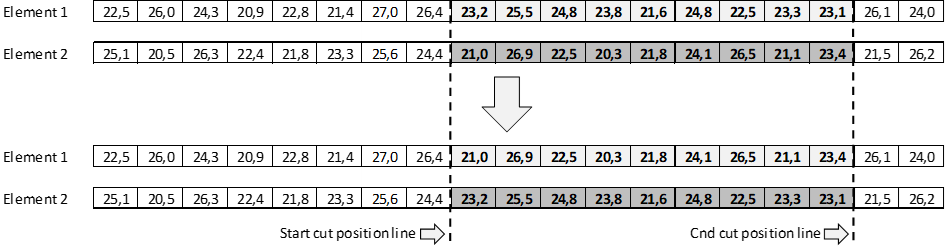

  

In [ ]:
# =========================================================
# GENETIC ALGORITHM SETUP WITH DEAP
# =========================================================

population_size = 50
generation_Size = 50
mutpb = 0.2 # Mutationswahrscheinlichkeit
cxpb = 0.7 # Crossoverwahrscheinlichkeit

creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()
toolbox.register("attr_bin", random.randint, 0, 2)

if IMPORTS_SUCCESSFUL:
    try:
        pv_hourly = pv_mod['P_PV_out_AC'].resample("h").mean()
        hours_total = len(pv_hourly)
    except:
        hours_total = 24
else:
    hours_total = 24
hours_total = max(1, hours_total)

toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bin, n=hours_total)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def evaluate_schedule(individual, simulation_data):
    results = core_simulation(simulation_data, schedule=individual)
    return (results["costs"].sum(),)

toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)

print("--- EMS Optimierung & Vergleich (Rein stündliche Basis 2026) ---")
sim_data = load_and_merge_to_pv_horizon() #.iloc[:24]

# 1. Baseline berechnen
print("\nBerechne Baseline-Szenario (Rein PV-basiert, ohne GA)...")
df_baseline = core_simulation(sim_data, schedule=[0] * hours_total)
baseline_costs = df_baseline["costs"].sum()

# 2. GA Optimierung vorbereiten
toolbox.register("evaluate", evaluate_schedule, simulation_data=sim_data)
pop = toolbox.population(n=population_size)
hof = tools.HallOfFame(1)

# Statistiken für den Boxplot
stats = tools.Statistics(key=lambda ind: ind.fitness.values[0])
stats.register("raw_fitness", lambda x: list(x))
stats.register("min", np.min)

print(f"\nStarte GA-Optimierung über {hours_total} Stunden...")
print(f"{'Gen':<6}{'Evaluations':<13}{'Beste Fitness (Min)':<20}")
print("-" * 42)

# Wir initialisieren das Logbook und die Hall of Fame
from deap import algorithms
logbook = tools.Logbook()
logbook.header = ['gen', 'nevals'] + stats.fields

# 0. Generation berechnen
invalid_ind = [ind for ind in pop if not ind.fitness.valid]
fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
for ind, fit in zip(invalid_ind, fitnesses):
    ind.fitness.values = fit

hof.update(pop)
record = stats.compile(pop)
logbook.record(gen=0, nevals=len(invalid_ind), **record)

# Print für Generation 0
print(f"{0:<6}{len(invalid_ind):<13}{record['min']:.5f}")

# Generationen durchlaufen
for gen in range(1, generation_Size + 1):
    # Selektion, Kreuzung und Mutation
    pop = toolbox.select(pop, len(pop))
    pop = algorithms.varAnd(pop, toolbox, cxpb=cxpb, mutpb=mutpb)

    # Fitness der neuen Individuen berechnen
    invalid_ind = [ind for ind in pop if not ind.fitness.valid]
    fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    # Hall of Fame und Statistiken updaten
    hof.update(pop)
    record = stats.compile(pop)
    logbook.record(gen=gen, nevals=len(invalid_ind), **record)

    print(f"{gen:<6}{len(invalid_ind):<13}{record['min']:.5f}")

# Bestes Ergebnis auswerten
best_schedule = hof[0]
df_results_opt = core_simulation(sim_data, schedule=best_schedule)
opt_costs = df_results_opt["costs"].sum()

print(f"\nOptimierung abgeschlossen!")
print(f"Baseline-Kosten: {baseline_costs:.2f} €")
print(f"Optimierte Kosten: {opt_costs:.2f} €")

# --- DATEN AUS DEM LOGBOOK EXTRAHIEREN & PLOTTEN (Bleibt exakt gleich!) ---
generations = logbook.select("gen")
raw_history = logbook.select("raw_fitness")

plot_interval = 5
filtered_history = [raw_history[i] for i in range(0, len(raw_history), plot_interval)]
filtered_gens = [generations[i] for i in range(0, len(generations), plot_interval)]

plt.figure(figsize=(12, 6))
plt.boxplot(filtered_history, positions=filtered_gens, widths=2)
plt.xlabel("Generation")
plt.ylabel("Kosten [€]")
plt.title("Entwicklung der Fitness-Verteilung (Populations-Diversität)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

##Schritt 4.1 Plot Vergleich Basis- und optimierter Betrieb

In [ ]:
# =========================================================
# PLOTTING
# =========================================================
# Fenster 1: Baseline
plt.figure(1, figsize=(14, 6))
ax_base = plt.gca()
ax_base.plot(df_baseline.index, df_baseline['SOC'], label='Speicher-SOC [kWh]', color='blue', linewidth=2.5)
ax_base.plot(df_baseline.index, df_baseline['pv'], label='PV-Ertrag [kW]', color='orange', alpha=0.8, linewidth=2)
ax_base.plot(df_baseline.index, df_baseline['demand_el'], label='Elektrische Last [kW]', color='black', alpha=0.5, linestyle='--')

ax_base_price = ax_base.twinx()
ax_base_price.plot(df_baseline.index, df_baseline['tariff'], color='red', alpha=0.3, linestyle=':')
ax_base_price.set_ylabel('Strompreis [€/kWh]', color='black', alpha=1)
ax_base_price.tick_params(axis='y', colors='black', labelcolor='black')

ax_base.set_title(f"1. Baseline: Reine Eigenverbrauchsoptimierung (Gesamtkosten: {baseline_costs:.2f} €)")
ax_base.set_xlabel("Zeitverlauf (Stunden)")
ax_base.set_ylabel("Leistung [kW] / SOC [kWh]")
ax_base.grid(True, alpha=0.3)
lines_b, labels_b = ax_base.get_legend_handles_labels()
ax_base.legend(lines_b, labels_b, loc="upper left")
plt.tight_layout()
plt.show(block=False)

# Fenster 2: GA-Optimiert
plt.figure(2, figsize=(14, 6))
ax_opt = plt.gca()
ax_opt.plot(df_results_opt.index, df_results_opt['SOC'], label='Speicher-SOC [kWh]', color='blue', linewidth=2.5)
ax_opt.plot(df_results_opt.index, df_results_opt['pv'], label='PV-Ertrag [kW]', color='orange', alpha=0.8, linewidth=2)
ax_opt.plot(df_results_opt.index, df_results_opt['demand_el'], label='Elektrische Last [kW]', color='black', alpha=0.5, linestyle='--')

# GA-Befehle visualisieren
ax_opt.fill_between(df_results_opt.index, 0, C_Batt_storage, where=df_results_opt["battery_charge_signal"] == 1, color='green', alpha=0.12, label='Netz-Ladebefehl aktiv (GA)')
ax_opt.fill_between(df_results_opt.index, 0, C_Batt_storage, where=df_results_opt["battery_charge_signal"] == 2, color='red', alpha=0.12, label='Arbitrage-Entladebefehl aktiv (GA)')

ax_opt_price = ax_opt.twinx()
tariff = df_results_opt['tariff']
ax_opt_price.plot(df_results_opt.index, tariff, label='Strompreis [€/kWh]', color='red', linewidth=1.8)
ax_opt_price.fill_between(df_results_opt.index, tariff, color='red', alpha=0.08)
ax_opt_price.set_ylabel('Strompreis [€/kWh]', color='black')
ax_opt_price.tick_params(axis='y', colors='black')

ymin, ymax = tariff.min(), tariff.max()
margin = (ymax - ymin) * 0.15 if ymax > ymin else 0.01
ax_opt_price.set_ylim(ymin - margin, ymax + margin)

ax_opt.set_title(f"2. GA-Optimiert: Arbitrage & Netzsteuerung (Gesamtkosten: {opt_costs:.2f} €)")
ax_opt.set_xlabel("Zeitverlauf (Stunden)")
ax_opt.set_ylabel("Leistung [kW] / SOC [kWh]")
ax_opt.grid(True, alpha=0.3)
lines_o1, labels_o1 = ax_opt.get_legend_handles_labels()
lines_o2, labels_o2 = ax_opt_price.get_legend_handles_labels()
ax_opt.legend(lines_o1 + lines_o2, labels_o1 + labels_o2, loc="upper left")
plt.tight_layout()
plt.show(block=False)

# Fenster 3: Gemeinsamer Kostenvergleich
plt.figure(3, figsize=(14, 6))
cum_costs_baseline = df_baseline['costs'].cumsum()
cum_costs_opt = df_results_opt['costs'].cumsum()
plt.plot(df_baseline.index, cum_costs_baseline, color='darkred', linewidth=2.5, label=f'Baseline (Endstand: {baseline_costs:.2f} €)')
plt.plot(df_results_opt.index, cum_costs_opt, color='darkgreen', linewidth=2.5, label=f'GA-Optimiert (Endstand: {opt_costs:.2f} €)')
plt.fill_between(df_baseline.index, cum_costs_baseline, cum_costs_opt, where=(cum_costs_baseline > cum_costs_opt), color='green', alpha=0.15, label=f'Kumulierte Ersparnis ({baseline_costs - opt_costs:.2f} €)')
plt.title("Direkter ökonomischer Vergleich: Kumulierte Gesamtkosten")
plt.xlabel("Zeitverlauf (Stunden)")
plt.ylabel("Kosten [€]")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left", fontsize=11)
plt.tight_layout()
plt.show()